from previous visualization:
- no missing values

  
count of days :
- algeria: 364
- tunisia : 353
  
but end and start day are the same

creating target variable :
 - créer la target à partir de la colonne type et confidence et après ça tu supprime toutes les autres colonnes sauf latitude et longitude




# Importing env and libaries

In [1]:
import geopandas as gpd
import pandas as pd
import rasterio
from rasterio.mask import mask
import matplotlib.pyplot as plt
import rasterio
from rasterio.plot import show
import matplotlib.pyplot as plt
import numpy as np

In [2]:
from dotenv import load_dotenv
import os
from pathlib import Path

def load_environment():
    """Load environment variables and return them as a dictionary."""
    load_dotenv(Path("../utils/.env"))  # Loads .env from project root (works if run from notebook too)
    env_vars = {
        "IMAGE_FOLDER": os.getenv("IMAGE_FOLDER"),
        "EXTRACTEDDATASET_FOLDER": os.getenv("EXTRACTEDDATASET_FOLDER"),
        "DATASETS_FOLDER": os.getenv("DATASETS_FOLDER"),
        "ElevationDataset": os.getenv("ElevationDataset"),
        "LandCoverDataset": os.getenv("LandCoverDataset"),
        "GeoBoundaries": os.getenv("GeoBoundaries"),
        "EXTRACTEDELEVATION_FOLDER": os.getenv("EXTRACTEDELEVATION_FOLDER"),
        "EXTRACTEDLANDCOVER_FOLDER": os.getenv("EXTRACTEDLANDCOVER_FOLDER"),
        "EXTRACTEDGEOBOUNDARIES_FOLDER": os.getenv("EXTRACTEDGEOBOUNDARIES_FOLDER"),
        "CLEANEDDATASET_FOLDER": os.getenv("CLEANEDDATASET_FOLDER"),
        "CLEANEDELEVATION_FOLDER": os.getenv("CLEANEDELEVATION_FOLDER"),
        "CLEANEDLANDCOVER_FOLDER": os.getenv("CLEANEDLANDCOVER_FOLDER"),
        "PREPROCESSED_DATASET_FOLDER": os.getenv("PREPROCESSED_DATASET_FOLDER"),
        "PREPROCESSED_ELEVATION_FOLDER": os.getenv("PREPROCESSED_ELEVATION_FOLDER"),
        "PREPROCESSED_LANDCOVER_FOLDER": os.getenv("PREPROCESSED_LANDCOVER_FOLDER")
    }
    return env_vars

folders = load_environment()
image_folder = folders["IMAGE_FOLDER"]
extractedData_folder = folders["EXTRACTEDDATASET_FOLDER"]
datasets_folder = folders["DATASETS_FOLDER"]
landCover_folder = folders["LandCoverDataset"]
elevation_folder = folders["ElevationDataset"]
geoboundaries_folder = folders["GeoBoundaries"]
extracted_elevation_folder = folders["EXTRACTEDELEVATION_FOLDER"]
extracted_landcover_folder = folders["EXTRACTEDLANDCOVER_FOLDER"]
extracted_geo_boundaries_folder = folders["EXTRACTEDGEOBOUNDARIES_FOLDER"]
cleaned_dataset_folder = folders["CLEANEDDATASET_FOLDER"]
cleaned_elevation_folder = folders["CLEANEDELEVATION_FOLDER"]
cleaned_landcover_folder = folders["CLEANEDLANDCOVER_FOLDER"]
preprocessed_dataset_folder = folders["PREPROCESSED_DATASET_FOLDER"]
preprocessed_elevation_folder = folders["PREPROCESSED_ELEVATION_FOLDER"]
preprocessed_landcover_folder = folders["PREPROCESSED_LANDCOVER_FOLDER"]


# Reading the file

In [3]:
#  get fire geojson from f"{datasets_folder}/FireDataset/fires_dz_tn.geojson"
fire_df = pd.read_csv(f"{datasets_folder}/FireDataset/fire_df.csv")

# viewing   the first few rows of the geodataframe
fire_df.head()

# print(len(fire_df))  # --> 90250


,latitude,longitude,bright_ti4,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_ti5,frp,daynight,type
0,27.72818,9.87200,295.51,0.76,0.77,2024-01-01,3,N20,VIIRS,n,2,277.66,1.24,N,2
1,28.63288,9.77909,301.80,0.79,0.78,2024-01-01,3,N20,VIIRS,n,2,277.05,1.57,N,2
2,28.64012,9.77953,298.65,0.79,0.78,2024-01-01,3,N20,VIIRS,n,2,277.04,1.34,N,2
3,36.74886,6.25409,338.04,0.46,0.39,2024-01-01,141,N20,VIIRS,n,2,257.28,5.21,N,2
4,35.87978,4.44782,309.49,0.41,0.37,2024-01-01,141,N20,VIIRS,n,2,272.08,1.58,N,2


# preprocessing

<>:19: SyntaxWarning: invalid escape sequence '\l'
<>:19: SyntaxWarning: invalid escape sequence '\l'
C:\Users\moous\AppData\Local\Temp\ipykernel_71120\1534387213.py:19: SyntaxWarning: invalid escape sequence '\l'
  print("\longitude quantiles:")


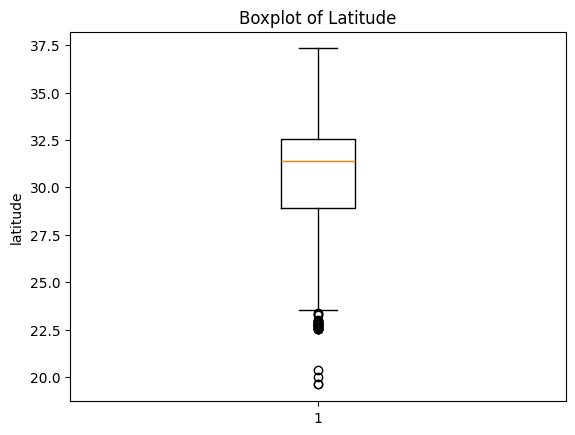


Latitude quantiles:
0.00    19.603230
0.25    28.911510
0.50    31.409125
0.75    32.560313
1.00    37.323460
Name: latitude, dtype: float64


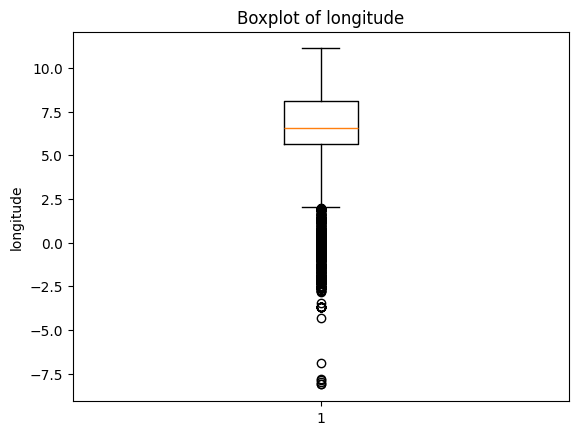

\longitude quantiles:
0.00    -8.118050
0.25     5.642160
0.50     6.557880
0.75     8.083758
1.00    11.110350
Name: longitude, dtype: float64


In [4]:
#  view longtitude boxplot to know where to cut --> to add non fire rows
import matplotlib.pyplot as plt

plt.boxplot(fire_df['latitude'])
plt.title("Boxplot of Latitude")
plt.ylabel("latitude")
plt.show()

#  print quantiles
print("\nLatitude quantiles:")
print(fire_df['latitude'].quantile([0, 0.25, 0.5, 0.75, 1]))

plt.boxplot(fire_df['longitude'])
plt.title("Boxplot of longitude")
plt.ylabel("longitude")
plt.show()

#  print quantiles
print("\longitude quantiles:")
print(fire_df['longitude'].quantile([0, 0.25, 0.5, 0.75, 1]))


latitude north is mostly whithin 30 and 37.5 ( view in fire visualiation map latitude lontitude vs FRP) --> fill those with negative fire

In [5]:
# keep latitude longtitude confidence type columns only
fire_df = fire_df[['latitude','longitude','type']]

# create dataframe where type= 1 for forest fires
fire_type0_df = fire_df[fire_df['type'] == 0]
fire_type0_df.head()
print(len(fire_type0_df))

14216


In [6]:
# add a column fire 
fire_df['fire'] = (fire_df['type'] == 0).astype(int)

# print where fire=1
firetype1_df = fire_df[fire_df['fire'] ==1]


## completer non fire 

In [7]:
landcover = gpd.read_file(f"{preprocessed_landcover_folder}/preprocessed_landcover")

convert landcover to geo dataframe

In [8]:
print("length of landcover ", len(landcover))
print("length of fire type 1 ", len(firetype1_df))

length of landcover  438513
length of fire type 1  14216


In [9]:
import geopandas as gpd

# Convert fire_df to GeoDataFrame
firetype1_df = gpd.GeoDataFrame(
    firetype1_df,
    geometry=gpd.points_from_xy(firetype1_df.longitude, firetype1_df.latitude),
    crs="EPSG:4326"
)

In [10]:
firetype1_df.head()

,latitude,longitude,type,fire,geometry
5,35.70751,5.53337,0,1,POINT (5.53337 35.70751)
13,32.13579,6.46961,0,1,POINT (6.46961 32.13579)
20,32.35563,6.97630,0,1,POINT (6.9763 32.35563)
64,28.19791,9.39581,0,1,POINT (9.39581 28.19791)
67,28.12826,9.49323,0,1,POINT (9.49323 28.12826)


In [11]:
firetype1_df = firetype1_df[['fire','geometry']]

In [12]:
# save geodataframe fire type 1 in preprocessed folder inside FireDataset
# Create output directory
output_dir = f"{preprocessed_dataset_folder}\FireDataset"
os.makedirs(output_dir, exist_ok=True)

# Define output file path (choose your preferred format)
output_path = os.path.join(output_dir, "fire_type_1.geojson")

# Save GeoDataFrame
firetype1_df.to_file(output_path, driver="GeoJSON")

print(f"Saved: {output_path}")

<>:3: SyntaxWarning: invalid escape sequence '\F'
<>:3: SyntaxWarning: invalid escape sequence '\F'
C:\Users\moous\AppData\Local\Temp\ipykernel_71120\16935183.py:3: SyntaxWarning: invalid escape sequence '\F'
  output_dir = f"{preprocessed_dataset_folder}\FireDataset"


Saved: ../../PreprocessedDatasets\FireDataset\fire_type_1.geojson


⚙️ Why the joined table is longer than either input

Each landcover polygon can intersect multiple fire points,
and each fire point can intersect one polygon.

In [13]:
fire_with_landcover_right = gpd.sjoin(firetype1_df, landcover, how="right", predicate="intersects")
print(len(fire_with_landcover_right))

451331


In [14]:
# count how many empty fire 
# For your fire_with_landcover GeoDataFrame
missing_counts = fire_with_landcover_right.isna().sum()
print(missing_counts)


index_left          437122
fire                437122
area                     0
lcc_Bare lands           0
lcc_Croplands            0
lcc_Forests              0
lcc_Grasslands           0
lcc_Vegetation           0
lcc_Water bodies         0
geometry                 0
dtype: int64


In [15]:
fire_with_landcover_right['fire'].unique()

array([nan,  1.])

In [16]:
fire_with_landcover_right['fire'] = fire_with_landcover_right['fire'].fillna(0).astype(int)

In [ ]:
# import matplotlib.pyplot as plt

# # Simplify geometry
# fire_simple = fire_with_landcover_right.copy()
# fire_simple['geometry'] = fire_simple.geometry.simplify(0.001)

# # Plot
# fire_simple.plot(column='fire', legend=True, figsize=(10, 10))
# plt.show()
